In [13]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# # Load the image
# image_path = "../apple_scab.JPG"
# image = cv2.imread(image_path)

# # Convert the image to grayscale
# image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# # Resize the grayscale image
# image_resized = cv2.resize(image_gray, (224, 224))

# # Apply Gaussian Blur
# image_blurred = cv2.GaussianBlur(image_resized, (5, 5), 0)

# # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
# clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
# image_clahe = clahe.apply(image_blurred)


# # Set up the plot
# fig, axes = plt.subplots(1, 5, figsize=(20, 10))

# # Raw Image (converted to RGB for visualization)
# axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# axes[0].set_title("Step 0: Raw Image")
# axes[0].axis('off')

# # Grayscale Image
# axes[1].imshow(image_gray, cmap='gray')
# axes[1].set_title("Step 1: Convert to Grayscale")
# axes[1].axis('off')

# # Resized Grayscale Image
# axes[2].imshow(image_resized, cmap='gray')
# axes[2].set_title("Step 2: Resized")
# axes[2].axis('off')

# # Blurred Grayscale Image
# axes[3].imshow(image_blurred, cmap='gray')
# axes[3].set_title("Step 3: Noise Reduction")
# axes[3].axis('off')

# # CLAHE Grayscale Image
# axes[4].imshow(image_clahe, cmap='gray')
# axes[4].set_title("Step 4: CLAHE applied")
# axes[4].axis('off')

# # Add arrows between steps
# for i in range(4):
#     axes[i].annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5))

# # Show the plot
# plt.tight_layout()
# plt.show()
# plt.savefig("../data/preprocessed/applescab_gray.png")


In [4]:
import os
import cv2
import numpy as np
import random
import shutil
from tqdm import tqdm
import albumentations as A

# Paths
input_dir = '../data/Leaf/raw/selected'  # Directory containing the processed dataset
output_dir = '../data/Leaf/raw/selectedfinal'  # Directory to save balanced dataset

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Define augmentation pipeline
augmentations = [
    A.HorizontalFlip(p=1.0),
    A.VerticalFlip(p=1.0),
    A.RandomRotate90(p=1.0),
    A.Transpose(p=1.0),
]

# Function to apply a random augmentation
def augment_image(image):
    transform = random.choice(augmentations)
    augmented = transform(image=image)['image']
    return augmented

# Process each class
for class_name in tqdm(os.listdir(input_dir)):
    class_path = os.path.join(input_dir, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    output_class_dir = os.path.join(output_dir, class_name)
    os.makedirs(output_class_dir, exist_ok=True)
    
    # Get all images in the class folder
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    num_images = len(image_files)
    
    if num_images > 2000:
        # Reduce dataset to 2000 by random selection
        selected_images = random.sample(image_files, 2000)
        for img_file in selected_images:
            shutil.copy(os.path.join(class_path, img_file), os.path.join(output_class_dir, img_file))
    else:
        # Augment images to reach 2000
        for img_file in image_files:
            shutil.copy(os.path.join(class_path, img_file), os.path.join(output_class_dir, img_file))
        
        while len(os.listdir(output_class_dir)) < 2000:
            img_file = random.choice(image_files)
            image_path = os.path.join(class_path, img_file)
            image = cv2.imread(image_path)
            
            if image is None:
                continue
            
            augmented_image = augment_image(image)
            new_img_name = f"aug_{len(os.listdir(output_class_dir))}_{img_file}"
            cv2.imwrite(os.path.join(output_class_dir, new_img_name), augmented_image)

print("Dataset balancing complete! All classes now have 2000 images.")


100%|██████████| 22/22 [04:35<00:00, 12.53s/it]

Dataset balancing complete! All classes now have 2000 images.


In [7]:
dir = "../data/leaf/"
train_dir = dir + "/raw/selectedfinal"
valid_dir = dir + "/valid"
test_dir = dir + "/test"
disease_class = os.listdir(train_dir)

C:\Users\Acer\AppData\Local\Temp\ipykernel_9188\4158376142.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= Len, y= plant_names, palette="Greens")


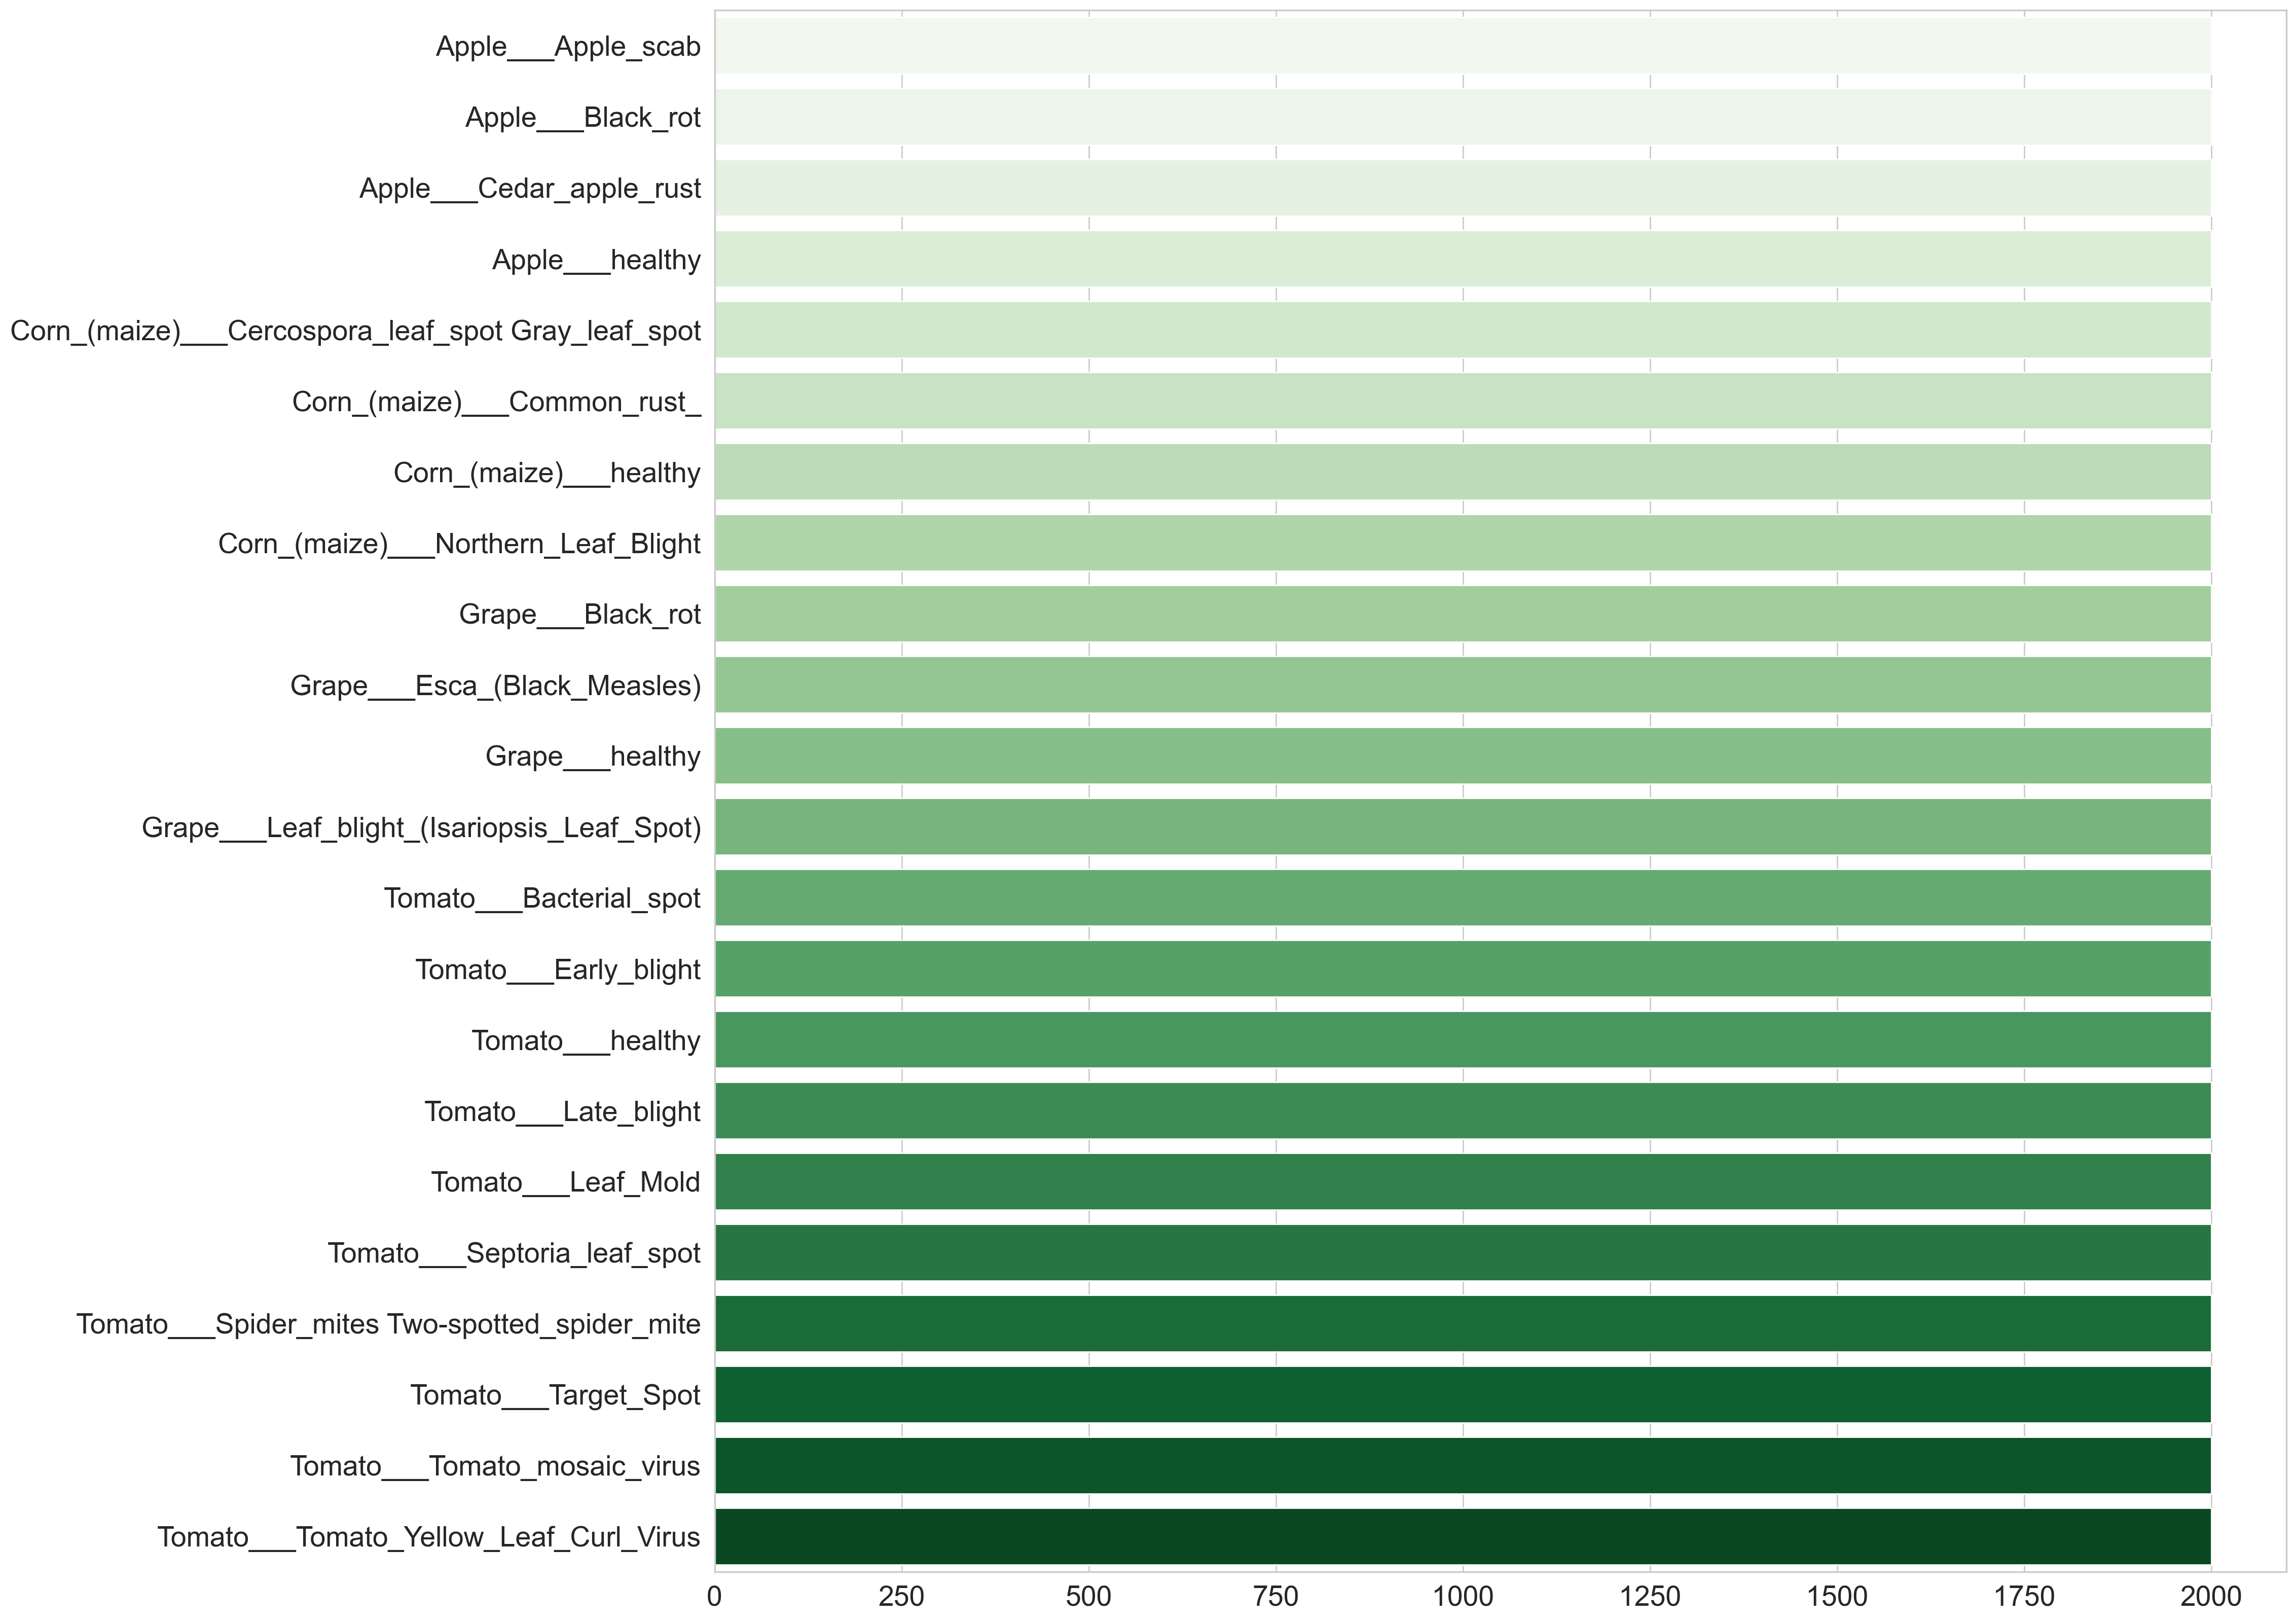

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plant_names = []
Len = []
for i in disease_class:
    plant_names.append(i)
    imgs_path = os.listdir(train_dir + "/" + i)
    Len.append(len(imgs_path))

Len.sort(reverse=True)

sns.set(style="whitegrid", color_codes=True)
plt.figure(figsize=(20,20),dpi=200)
ax = sns.barplot(x= Len, y= plant_names, palette="Greens")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [3]:
# import os
# import cv2
# import numpy as np
# import albumentations as A
# from tqdm import tqdm
# import random

# # Paths
# input_dir = '../data/Leaf/raw/grayscale'  # Original dataset directory with 38 classes
# output_dir = '../data/Leaf/raw/processed_train'  # Directory to save augmented images

# # Create the output directory if it doesn't exist
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# # Define augmentation and preprocessing pipeline
# def preprocess_image(image):
#     # Convert the image to grayscale
#     # image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     # Apply Gaussian Blur
#     # image_blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)

#     # Apply Noise Reduction (using Non-Local Means Denoising)
#     # image_denoised = cv2.fastNlMeansDenoising(image_blurred, None, 10, 7, 21)

#     # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
#     # clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
#     # image_clahe = clahe.apply(image_denoised)

#     # Normalize the image (scale to range [0, 1])
#     image_normalized = image.astype('float32') / 255.0

#     # Apply augmentation (this can be done after resizing)
#     transform = A.Compose([
#         A.RandomBrightnessContrast(p=0.5),  # Random brightness and contrast
#         A.HorizontalFlip(p=0.5),  # Random horizontal flip
#         # A.Rotate(limit=90, p=1.0, border_mode=cv2.BORDER_CONSTANT),  # Rotate by 90 degrees
#         # A.RandomCrop(width=200, height=200, p=0.5),  # Random crop
#         A.RandomGamma(p=0.5),  # Random gamma correction
#     ])
    
#     augmented = transform(image=image_normalized)
#     image_resized = cv2.resize(augmented['image'], (224, 224))  # Correctly extract and resize the augmented image

#     # Convert augmented image back to [0, 255] range for saving
#     augmented_image_uint8 = (image_resized * 255).astype(np.uint8)

#     return augmented_image_uint8

# # Get all class names (subfolders in the input directory)
# class_names = os.listdir(input_dir)

# # Process each class
# for class_name in tqdm(class_names):
#     class_path = os.path.join(input_dir, class_name)
    
#     # Skip if it's not a directory
#     if not os.path.isdir(class_path):
#         continue

#     # Create the corresponding class folder in the output directory
#     output_class_dir = os.path.join(output_dir, class_name)
#     if not os.path.exists(output_class_dir):
#         os.makedirs(output_class_dir)

#     # Get all images in the class folder
#     image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
#     # Select 50 random images (if there are more than 50)
#     selected_images = random.sample(image_files, min(50, len(image_files)))

#     # Process each selected image
#     for image_file in selected_images:
#         image_path = os.path.join(class_path, image_file)

#         # Check if the image exists and is valid
#         print(f"Loading image from: {image_path}")
#         image = cv2.imread(image_path)

#         if image is None or image.size == 0:
#             print(f"Skipping invalid image: {image_path}")
#             continue  # Skip invalid image

#         # Preprocess and augment the image
#         processed_image = preprocess_image(image)

#         # Save the processed (augmented) image
#         augmented_image_save_path = os.path.join(output_class_dir, f"augmented_{image_file}")
#         cv2.imwrite(augmented_image_save_path, processed_image)

# print("Image preprocessing, augmentation, and saving complete!")


In [79]:
# import os
# import cv2
# import numpy as np
# import albumentations as A
# from tqdm import tqdm
# import random

# # Paths
# input_dir = '../data/Leaf/train'  # Original dataset directory with 38 classes
# output_dir = '../data/Leaf/augmented_grey_train'  # Directory to save augmented images

# # Create the output directory if it doesn't exist
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# # Define augmentation and preprocessing pipeline
# def preprocess_image(image):
#     # Convert the image to grayscale
#     image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     # Resize the grayscale image to 224x224
#     image_resized = cv2.resize(image_gray, (224, 224))

#     # Apply Gaussian Blur
#     image_blurred = cv2.GaussianBlur(image_resized, (5, 5), 0)

#     # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
#     clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
#     image_clahe = clahe.apply(image_blurred)

#     # Normalize the image (scale to range [0, 1])
#     image_normalized = image_clahe.astype('float32') / 255.0

#     # Apply augmentation
#     transform = A.Compose([
#         A.RandomBrightnessContrast(p=0.5),  # Random brightness and contrast
#         A.HorizontalFlip(p=0.5),  # Random horizontal flip
#         A.Rotate(limit=90, p=1.0, border_mode=cv2.BORDER_CONSTANT),  # Rotate by 90 degrees
#         A.RandomCrop(width=200, height=200, p=0.5),  # Random crop
#         A.RandomGamma(p=0.5),  # Random gamma correction
#     ])

#     augmented = transform(image=image_normalized)
#     augmented_image = augmented['image']

#     # Convert augmented image back to [0, 255] range for saving
#     augmented_image_uint8 = (augmented_image * 255).astype(np.uint8)

#     return augmented_image_uint8

# # Get all class names (subfolders in the input directory)
# class_names = os.listdir(input_dir)

# # Process each class
# for class_name in tqdm(class_names):
#     class_path = os.path.join(input_dir, class_name)
    
#     # Skip if it's not a directory
#     if not os.path.isdir(class_path):
#         continue

#     # Create the corresponding class folder in the output directory
#     output_class_dir = os.path.join(output_dir, class_name)
#     if not os.path.exists(output_class_dir):
#         os.makedirs(output_class_dir)

#     # Get all images in the class folder
#     image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
#     # Select 50 random images (if there are more than 50)
#     selected_images = random.sample(image_files, min(50, len(image_files)))

#     # Process each selected image
#     for image_file in selected_images:
#         image_path = os.path.join(class_path, image_file)

#         # Check if the image exists and is valid
#         print(f"Loading image from: {image_path}")
#         image = cv2.imread(image_path)

#         if image is None or image.size == 0:
#             print(f"Skipping invalid image: {image_path}")
#             continue  # Skip invalid image


#         # Preprocess and augment the image
#         processed_image = preprocess_image(image)

#         # Save the processed (augmented) image
#         augmented_image_save_path = os.path.join(output_class_dir, f"augmented_{image_file}")
#         cv2.imwrite(augmented_image_save_path, processed_image)

# print("Image preprocessing, augmentation, and saving complete!")


In [11]:
# import os
# import cv2
# import numpy as np
# import albumentations as A
# from tqdm import tqdm
# import random

# # Paths
# input_dir = '../data/Leaf/train'  # Original dataset directory with 38 classes
# output_dir = '../data/Leaf/augmented_grey_train'  # Directory to save augmented images

# # Create the output directory if it doesn't exist
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# # Define augmentation and preprocessing pipeline
# def preprocess_image(image):
#     # Convert the image to grayscale
#     image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     # Resize the grayscale image to 224x224
#     image_resized = cv2.resize(image_gray, (224, 224))

#     # Apply Gaussian Blur
#     image_blurred = cv2.GaussianBlur(image_resized, (5, 5), 0)

#     # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
#     clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
#     image_clahe = clahe.apply(image_blurred)

#     # Normalize the image (scale to range [0, 1])
#     image_normalized = image_clahe.astype('float32') / 255.0

#     # Apply augmentation
#     transform = A.Compose([
#         A.RandomBrightnessContrast(p=0.5),  # Random brightness and contrast
#         A.HorizontalFlip(p=0.5),  # Random horizontal flip
#         A.Rotate(limit=90, p=1.0, border_mode=cv2.BORDER_CONSTANT),  # Rotate by 90 degrees
#         A.RandomCrop(width=200, height=200, p=0.5),  # Random crop
#         A.RandomGamma(p=0.5),  # Random gamma correction
#     ])

#     augmented = transform(image=image_normalized)
#     augmented_image = augmented['image']

#     # Convert augmented image back to [0, 255] range for saving
#     augmented_image_uint8 = (augmented_image * 255).astype(np.uint8)

#     return augmented_image_uint8

# # Get all class names (subfolders in the input directory)
# class_names = os.listdir(input_dir)

# # Process each class
# for class_name in tqdm(class_names):
#     class_path = os.path.join(input_dir, class_name)
    
#     # Skip if it's not a directory
#     if not os.path.isdir(class_path):
#         continue

#     # Create the corresponding class folder in the output directory
#     output_class_dir = os.path.join(output_dir, class_name)
#     if not os.path.exists(output_class_dir):
#         os.makedirs(output_class_dir)

#     # Get all images in the class folder
#     image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
#     # Select 50 random images (if there are more than 50)
#     selected_images = random.sample(image_files, min(50, len(image_files)))

#     # Process each selected image
#     for image_file in selected_images:
#         image_path = os.path.join(class_path, image_file)

#         # Check if the image exists and is valid
#         print(f"Loading image from: {image_path}")
#         image = cv2.imread(image_path)

#         if image is None or image.size == 0:
#             print(f"Skipping invalid image: {image_path}")
#             continue  # Skip invalid image


#         # Preprocess and augment the image
#         processed_image = preprocess_image(image)

#         # Save the processed (augmented) image
#         augmented_image_save_path = os.path.join(output_class_dir, f"augmented_{image_file}")
#         cv2.imwrite(augmented_image_save_path, processed_image)

# print("Image preprocessing, augmentation, and saving complete!")


In [16]:
# import os
# import cv2
# import numpy as np
# import albumentations as A
# from tqdm import tqdm
# import random

# # Paths
# input_dir = '../data/Leaf/valid'  # Original dataset directory with 38 classes
# output_dir = '../data/Leaf/augmented_grey_valid'  # Directory to save augmented images

# # Create the output directory if it doesn't exist
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# # Define augmentation and preprocessing pipeline
# def preprocess_image(image):
#     # Convert the image to grayscale
#     image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     # Resize the grayscale image to 224x224

#     # Apply Gaussian Blur
#     image_blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)

#     # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
#     clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
#     image_clahe = clahe.apply(image_blurred)

#     # Normalize the image (scale to range [0, 1])
#     image_normalized = image_clahe.astype('float32') / 255.0

#     # Apply augmentation
#     transform = A.Compose([
#         A.RandomBrightnessContrast(p=0.5),  # Random brightness and contrast
#         A.HorizontalFlip(p=0.5),  # Random horizontal flip
#         A.Rotate(limit=90, p=1.0, border_mode=cv2.BORDER_CONSTANT),  # Rotate by 90 degrees
#         A.RandomCrop(width=200, height=200, p=0.5),  # Random crop
#         A.RandomGamma(p=0.5),  # Random gamma correction
#     ])
#     image_resized = cv2.resize(image_normalized, (224, 224))

#     augmented = transform(image=image_resized)
#     augmented_image = augmented['image']

#     # Convert augmented image back to [0, 255] range for saving
#     augmented_image_uint8 = (augmented_image * 255).astype(np.uint8)

#     return augmented_image_uint8

# # Get all class names (subfolders in the input directory)
# class_names = os.listdir(input_dir)

# # Process each class
# for class_name in tqdm(class_names):
#     class_path = os.path.join(input_dir, class_name)
    
#     # Skip if it's not a directory
#     if not os.path.isdir(class_path):
#         continue

#     # Create the corresponding class folder in the output directory
#     output_class_dir = os.path.join(output_dir, class_name)
#     if not os.path.exists(output_class_dir):
#         os.makedirs(output_class_dir)

#     # Get all images in the class folder
#     image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
#     # Select 50 random images (if there are more than 50)
#     selected_images = random.sample(image_files, min(20, len(image_files)))

#     # Process each selected image
#     for image_file in selected_images:
#         image_path = os.path.join(class_path, image_file)

#         # Check if the image exists and is valid
#         print(f"Loading image from: {image_path}")
#         image = cv2.imread(image_path)

#         if image is None or image.size == 0:
#             print(f"Skipping invalid image: {image_path}")
#             continue  # Skip invalid image


#         # Preprocess and augment the image
#         processed_image = preprocess_image(image)

#         # Save the processed (augmented) image
#         augmented_image_save_path = os.path.join(output_class_dir, f"augmented_{image_file}")
#         cv2.imwrite(augmented_image_save_path, processed_image)

# print("Image preprocessing, augmentation, and saving complete!")


In [12]:
# import os
# import cv2
# import numpy as np
# import albumentations as A
# from tqdm import tqdm
# import random

# # Paths
# input_dir = '../data/Leaf/train'  # Original dataset directory with 38 classes
# output_dir = '../data/Leaf/augmented_grey_train'  # Directory to save augmented images

# # Create the output directory if it doesn't exist
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# # Define augmentation and preprocessing pipeline
# def preprocess_image(image):
#     # Convert the image to grayscale
#     image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     # Resize the grayscale image to 224x224

#     # Apply Gaussian Blur
#     image_blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)

#     # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
#     clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
#     image_clahe = clahe.apply(image_blurred)

#     # Normalize the image (scale to range [0, 1])
#     image_normalized = image_clahe.astype('float32') / 255.0

#     # Apply augmentation
#     transform = A.Compose([
#         A.RandomBrightnessContrast(p=0.5),  # Random brightness and contrast
#         A.HorizontalFlip(p=0.5),  # Random horizontal flip
#         A.Rotate(limit=90, p=1.0, border_mode=cv2.BORDER_CONSTANT),  # Rotate by 90 degrees
#         A.RandomCrop(width=200, height=200, p=0.5),  # Random crop
#         A.RandomGamma(p=0.5),  # Random gamma correction
#     ])
#     image_resized = cv2.resize(image_normalized, (224, 224))

#     augmented = transform(image=image_resized)
#     augmented_image = augmented['image']

#     # Convert augmented image back to [0, 255] range for saving
#     augmented_image_uint8 = (augmented_image * 255).astype(np.uint8)

#     return augmented_image_uint8

# # Get all class names (subfolders in the input directory)
# class_names = os.listdir(input_dir)

# # Process each class
# for class_name in tqdm(class_names):
#     class_path = os.path.join(input_dir, class_name)
    
#     # Skip if it's not a directory
#     if not os.path.isdir(class_path):
#         continue

#     # Create the corresponding class folder in the output directory
#     output_class_dir = os.path.join(output_dir, class_name)
#     if not os.path.exists(output_class_dir):
#         os.makedirs(output_class_dir)

#     # Get all images in the class folder
#     image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
#     # Select 50 random images (if there are more than 50)
#     selected_images = random.sample(image_files, min(50, len(image_files)))

#     # Process each selected image
#     for image_file in selected_images:
#         image_path = os.path.join(class_path, image_file)

#         # Check if the image exists and is valid
#         print(f"Loading image from: {image_path}")
#         image = cv2.imread(image_path)

#         if image is None or image.size == 0:
#             print(f"Skipping invalid image: {image_path}")
#             continue  # Skip invalid image


#         # Preprocess and augment the image
#         processed_image = preprocess_image(image)

#         # Save the processed (augmented) image
#         augmented_image_save_path = os.path.join(output_class_dir, f"augmented_{image_file}")
#         cv2.imwrite(augmented_image_save_path, processed_image)

# print("Image preprocessing, augmentation, and saving complete!")
